This notebook extracts whole volume and whole (middle slice) image deep learning metrics. 
These metrics are SAMMed3D and morphem extracted features.

In [ ]:
import logging
import os
import pathlib
import time
import urllib.request
import warnings
from multiprocessing import Pool, cpu_count

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns

# import tifffile
import torch
import torch.nn as nn
import umap
from file_reading import *
from image_analysis_3D.featurization_utils.sammed3d_featurizer import (
    call_whole_image_sammed3d_pipeline,
)
from image_analysis_3D.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torchvision import transforms as v2
from transformers import AutoModel

# Suppress transformers warnings
logging.getLogger("transformers").setLevel(logging.ERROR)

2026-03-01 14:19:45.083169: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def generate_umap_and_pca(
    feature_df: pd.DataFrame,
    metadata_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Apply standard scalar and fit umap + PCA to the data

    Parameters
    ----------
    feature_df : pd.DataFrame
        The dataframe containing the features extracted from the images
    metadata_df : pd.DataFrame
        The dataframe containing the metadata associated with the images

        **Note please ensure that the index of the metadata_df matches the index of the feature_df
    Returns
    -------
    pd.DataFrame
        The metadata dataframe with added UMAP and PCA embeddings
    """
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(feature_df)

    umap_model = umap.UMAP(n_components=2, random_state=42)
    umap_embeddings = umap_model.fit_transform(features_scaled)
    metadata_df["umap_1"] = umap_embeddings[:, 0]
    metadata_df["umap_2"] = umap_embeddings[:, 1]

    pca_model = PCA(n_components=2)
    pca_embeddings = pca_model.fit_transform(features_scaled)
    metadata_df["pca_1"] = pca_embeddings[:, 0]
    metadata_df["pca_2"] = pca_embeddings[:, 1]

    return metadata_df

In [3]:
# Noise Injector transformation


class SaturationNoiseInjector(nn.Module):
    def __init__(self, low=200, high=255):
        super().__init__()
        self.low = low
        self.high = high

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Run the forward pass of the SaturationNoiseInjector transformation.
        Parameters
        ----------
        x : torch.Tensor
                A tensor of shape (N, C, Y, X) representing the input image batch.

        Returns
        -------
        torch.Tensor
                A tensor of the same shape as input, with noise injected into saturated pixels.
        """
        channel = x[0].clone()
        noise = torch.empty_like(channel).uniform_(self.low, self.high)
        mask = (channel == 255).float()
        noise_masked = noise * mask
        channel[channel == 255] = 0
        channel = channel + noise_masked
        x[0] = channel
        return x


# Self Normalize transformation
class PerImageNormalize(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps
        self.instance_norm = nn.InstanceNorm2d(
            num_features=1,
            affine=False,
            track_running_stats=False,
            eps=self.eps,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3:
            x = x.unsqueeze(0)
        x = self.instance_norm(x)
        if x.shape[0] == 1:
            x = x.squeeze(0)
        return x


def featurize_2D_image_w_morphem(
    image_tensor: torch.Tensor, model: torch.nn.Module, device: torch.device
):
    # Bag of Channels (BoC) - process each channel independently
    with torch.no_grad():
        batch_feat = []
        image_tensor = image_tensor.to(device)

        for c in range(image_tensor.shape[1]):
            # Extract single channel: (N, C, H, W) -> (N, 1, H, W)
            # where:
            # N is batch size (1 in this case),
            # C is number of channels,
            # H and W are Y and X dimensions
            single_channel = image_tensor[:, c, :, :].unsqueeze(1)

            # Apply transforms
            single_channel = transform(single_channel.squeeze(1)).unsqueeze(1)

            # Extract features
            output = model.forward_features(single_channel)
            feat_temp = output["x_norm_clstoken"].cpu().detach().numpy()
            batch_feat.append(feat_temp)
    return batch_feat[0]


# load models
sam3dmed_checkpoint_url = (
    "https://huggingface.co/blueyo0/SAM-Med3D/resolve/main/sam_med3d_turbo.pth"
)
sam3dmed_checkpoint_path = pathlib.Path("../models/sam-med3d-turbo.pth").resolve()
if not sam3dmed_checkpoint_path.exists():
    sam3dmed_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(sam3dmed_checkpoint_url, str(sam3dmed_checkpoint_path))

# Load model - suppress unused weights warning
device = "cuda"
warnings.filterwarnings(
    "ignore",
    message="Some weights of the model checkpoint.*were not used when initializing.*",
)
warnings.filterwarnings(
    "ignore", category=UserWarning, module="torch.nn.modules.instancenorm"
)
morphem_model = AutoModel.from_pretrained("CaicedoLab/MorphEm", trust_remote_code=True)
morphem_model.to(device).eval()
# Define transforms
transform = v2.Compose(
    [
        SaturationNoiseInjector(),
        PerImageNormalize(),
        v2.Resize(size=(224, 224), antialias=True),
    ]
)

In [4]:
start_time = time.time()
# get starting memory (cpu)
start_mem = psutil.Process(os.getpid()).memory_info().rss / 1024**2

In [5]:
root_dir, in_notebook = init_notebook()
if in_notebook:
    import tqdm.notebook as tqdm
else:
    import tqdm
image_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot")).resolve(), root_dir
)

In [6]:
patients_file_path = pathlib.Path(f"{root_dir}/data/patient_IDs.txt").resolve()
patients = pd.read_csv(patients_file_path, header=None)[0].tolist()

In [7]:
# Suppress warnings
import warnings

warnings.filterwarnings(
    "ignore", category=UserWarning, module="torch.nn.modules.instancenorm"
)


# Define transforms (same as before)
class SaturationNoiseInjector(nn.Module):
    def __init__(self, low=200, high=255):
        super().__init__()
        self.low = low
        self.high = high

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        channel = x[0].clone()
        noise = torch.empty_like(channel).uniform_(self.low, self.high)
        mask = (channel == 255).float()
        noise_masked = noise * mask
        channel[channel == 255] = 0
        channel = channel + noise_masked
        x[0] = channel
        return x


class PerImageNormalize(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps
        self.instance_norm = nn.InstanceNorm2d(
            num_features=1,
            affine=False,
            track_running_stats=False,
            eps=self.eps,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3:
            x = x.unsqueeze(0)
        x = self.instance_norm(x)
        if x.shape[0] == 1:
            x = x.squeeze(0)
        return x


def featurize_2D_image_w_morphem_worker(
    image_tensor: torch.Tensor, model: torch.nn.Module, device: torch.device, transform
):
    with torch.no_grad():
        batch_feat = []
        image_tensor = image_tensor.to(device)

        for c in range(image_tensor.shape[1]):
            single_channel = image_tensor[:, c, :, :].unsqueeze(1)
            single_channel = transform(single_channel.squeeze(1)).unsqueeze(1)
            output = model.forward_features(single_channel)
            feat_temp = output["x_norm_clstoken"].cpu().detach().numpy()
            batch_feat.append(feat_temp)
    return batch_feat[
        0
    ]  # the channels are duplicated in the batch dimension, so we can just return the first one


transform = v2.Compose(
    [
        SaturationNoiseInjector(),
        PerImageNormalize(),
        v2.Resize(size=(224, 224), antialias=True),
    ]
)

In [8]:
# Build list of all patient/well_fov combinations to process
for patient_id in tqdm.tqdm(patients, desc="Processing patients", leave=True):
    input_dir = pathlib.Path(
        f"{image_base_dir}/data/{patient_id}/zstack_images/"
    ).resolve(strict=True)
    well_fovs = input_dir.glob("*")
    well_fovs = [f.stem for f in well_fovs if f.is_dir()]
    for well_fov in tqdm.tqdm(
        well_fovs, desc=f"Processing well FOVs for patient {patient_id}", leave=False
    ):
        input_dir = pathlib.Path(
            f"{image_base_dir}/data/{patient_id}/zstack_images/"
        ).resolve(strict=True)
        well_fov_dir = pathlib.Path(f"{input_dir}/{well_fov}").resolve(strict=True)
        # get all well fovs for this patient
        # Filter for only TIFF files to avoid reading non-image files
        images_to_load = [
            x for x in pathlib.Path(well_fov_dir).glob("*.tif*") if x.is_file()
        ]
        images_to_load = sorted(
            images_to_load, key=lambda x: x.stem.split("_")[1]
        )  # sort by channel
        for image_file in tqdm.tqdm(
            images_to_load,
            desc=f"Processing {patient_id} {well_fov} images",
            leave=False,
        ):
            images_to_process = {
                "patient": [],
                "well_fov": [],
                "2D_image": [],
                "3D_image": [],
                "channel": [],
            }
            channel = image_file.stem.split("_")[1]
            # save path
            feature_save_path = pathlib.Path(
                f"{image_base_dir}/data/{patient_id}/whole_image_features/{well_fov}_{channel}_whole_image_features.parquet"
            ).resolve()
            feature_save_path.parent.mkdir(exist_ok=True, parents=True)

            if feature_save_path.exists():
                continue

            try:
                image = read_zstack_image(image_file)
            except Exception as e:
                print(f"Skipping corrupted/invalid file {image_file.name}: {e}")
                continue

            if channel == "640" and patient_id == "NF0037_T1":
                print(
                    f"Padding missing slice for patient {patient_id}, channel {channel} {well_fov}"
                )
                # pad the 640 channel to copy the first slice to be the new first slice
                # the 640 channel for this patient is missing the first slice
                # we removed it due to corruptions
                first_slice = image[0:1, :, :]
                image = np.concatenate([first_slice, image], axis=0)

            # get the size of
            # max z projection
            max_z = np.max(image, axis=0)
            images_to_process["patient"].append(patient_id)
            images_to_process["well_fov"].append(well_fov)
            images_to_process["2D_image"].append(max_z)
            images_to_process["3D_image"].append(image)
            images_to_process["channel"].append(channel)

            if len(images_to_process["2D_image"]) == 0:
                print(
                    f"No images found for patient {patient_id}, well FOV {well_fov}, skipping..."
                )

            images = torch.stack(
                [
                    torch.tensor(img, dtype=torch.float32)
                    for img in images_to_process["2D_image"]
                ]
            )
            volumes = torch.stack(
                [
                    torch.tensor(vol, dtype=torch.float32)
                    for vol in images_to_process["3D_image"]
                ]
            )

            # images is now (B, Y, X), add channel dimension -> (B, 1, Y, X)
            images = images.unsqueeze(1)
            # Replicate channel 3 times to get (B, 3, Y, X)
            images = images.repeat(1, 3, 1, 1)

            feature_dict = {
                "patient": [],
                "well_fov": [],
                "feature_name": [],
                "feature_value": [],
            }

            # featurize with SAM-Med3D and CHAMMI75
            for image_index in range(volumes.shape[0]):
                # assign the channel id for this image
                channel_id = images_to_process["channel"][image_index]

                image_3D = volumes[image_index].cpu().numpy()
                output_dict = call_whole_image_sammed3d_pipeline(
                    image=image_3D,
                    SAMMed3D_model_path=str(sam3dmed_checkpoint_path),
                    feature_type="cls",
                )
                # add the sam-med3d features to the feature dict
                feature_dict["patient"].extend(
                    [f"{patient_id}"] * len(output_dict["feature_name"])
                )
                feature_dict["well_fov"].extend(
                    [f"{well_fov}"] * len(output_dict["feature_name"])
                )
                feature_dict["feature_name"].extend(
                    f"{channel_id}_{feature_name}"
                    for feature_name in output_dict["feature_name"]
                )
                feature_dict["feature_value"].extend(output_dict["value"])

            for image_index in range(images.shape[0]):
                image_2D = images[image_index]
                batch_feat = featurize_2D_image_w_morphem_worker(
                    image_2D.unsqueeze(0), morphem_model, device, transform
                )
                for f_idx, feature_value in enumerate(batch_feat[0]):
                    feature_name = f"{channel_id}_morphem75_feature_{f_idx}"
                    feature_dict["patient"].extend([f"{patient_id}"])
                    feature_dict["well_fov"].extend([f"{well_fov}"])
                    feature_dict["feature_name"].append(feature_name)
                    feature_dict["feature_value"].append(feature_value)

            df = pd.DataFrame(feature_dict)
            df = (
                df.pivot_table(
                    index=["patient", "well_fov"],
                    columns="feature_name",
                    values="feature_value",
                )
                .reset_index()
                .rename_axis(None, axis=1)
            )
            df.to_parquet(
                feature_save_path,
                index=False,
            )

Processing patients:   0%|          | 0/13 [00:00<?, ?it/s]

Processing well FOVs for patient NF0014_T1:   0%|          | 0/104 [00:00<?, ?it/s]

Processing NF0014_T1 E5-2 images:   0%|          | 0/5 [00:00<?, ?it/s]

Processing NF0014_T1 D5-2 images:   0%|          | 0/5 [00:00<?, ?it/s]

Processing NF0014_T1 G6-1 images:   0%|          | 0/5 [00:00<?, ?it/s]

...

Processing SARCO361_T1 D5-3 images:   0%|          | 0/5 [00:00<?, ?it/s]

Processing SARCO361_T1 D11-3 images:   0%|          | 0/5 [00:00<?, ?it/s]

Processing SARCO361_T1 C2-3 images:   0%|          | 0/5 [00:00<?, ?it/s]

Processing SARCO361_T1 F3-6 images:   0%|          | 0/5 [00:00<?, ?it/s]

Processing SARCO361_T1 C8-4 images:   0%|          | 0/5 [00:00<?, ?it/s]

In [9]:
end_time = time.time()
# get starting memory (cpu)
end_mem = psutil.Process(os.getpid()).memory_info().rss / 1024**2

print(f"Time taken: {end_time - start_time} seconds")
print(f"Memory used: {end_mem - start_mem} MB")

Time taken: 101.11611223220825 seconds
Memory used: 108.71875 MB


In [10]:
patient_ids_file_path = pathlib.Path(f"{root_dir}/data/patient_IDs.txt").resolve()
patient_ids = pd.read_csv(patient_ids_file_path, header=None)[0].tolist()

In [11]:
list_of_file_paths = []
for patient in patient_ids:
    whole_image_features_path = pathlib.Path(
        f"{image_base_dir}/data/{patient}/whole_image_features"
    ).resolve()
    if not whole_image_features_path.exists():
        continue

    list_of_file_paths.extend(list(whole_image_features_path.glob("*.parquet")))

# sort the file paths to ensure consistent order
list_of_file_paths = sorted(list_of_file_paths)
print(f"Found {len(list_of_file_paths)} files to combine.")

Found 20710 files to combine.


In [12]:
file_list_dict = {
    "patient": [],
    "well_fov": [],
    "channel": [],
    "file_path": [],
}
for file_path in list_of_file_paths:
    filename = file_path.stem
    parts = filename.split("_")
    patient_id = file_path.parent.parent.name
    well_fov = parts[0]
    channel = parts[1]

    file_list_dict["patient"].append(patient_id)
    file_list_dict["well_fov"].append(well_fov)
    file_list_dict["channel"].append(channel)
    file_list_dict["file_path"].append(str(file_path))
file_list_df = pd.DataFrame(file_list_dict)
file_list_df.head()

,patient,well_fov,channel,file_path
0,NF0014_T1,C10-1,405,/home/lippincm/mnt/bandicoot/NF1_organoid_data...
1,NF0014_T1,C10-1,488,/home/lippincm/mnt/bandicoot/NF1_organoid_data...
2,NF0014_T1,C10-1,555,/home/lippincm/mnt/bandicoot/NF1_organoid_data...
3,NF0014_T1,C10-1,640,/home/lippincm/mnt/bandicoot/NF1_organoid_data...
4,NF0014_T1,C10-1,TRANS,/home/lippincm/mnt/bandicoot/NF1_organoid_data...


In [13]:
df_list = []
# concat by channel
for channel in file_list_df["channel"].unique():
    channel_files = file_list_df[file_list_df["channel"] == channel]
    df = pd.concat(
        [pd.read_parquet(file_path) for file_path in channel_files["file_path"]],
        ignore_index=True,
    )
    df_list.append(df)
# merge each df in the df list on patient and well fov
# where each df in the df list is a different channel
merged_df = df_list[0]
for df in df_list[1:]:
    merged_df = merged_df.merge(df, on=["patient", "well_fov"], how="outer")
print(merged_df.shape)
merged_df.head()

(4142, 3842)


,patient,well_fov,405_CHAMMI75_feature_0,405_CHAMMI75_feature_1,405_CHAMMI75_feature_10,405_CHAMMI75_feature_100,405_CHAMMI75_feature_101,405_CHAMMI75_feature_102,405_CHAMMI75_feature_103,405_CHAMMI75_feature_104,...,TRANS_SAMMed3D_feature_90,TRANS_SAMMed3D_feature_91,TRANS_SAMMed3D_feature_92,TRANS_SAMMed3D_feature_93,TRANS_SAMMed3D_feature_94,TRANS_SAMMed3D_feature_95,TRANS_SAMMed3D_feature_96,TRANS_SAMMed3D_feature_97,TRANS_SAMMed3D_feature_98,TRANS_SAMMed3D_feature_99
0,NF0014_T1,C10-1,1.436846,-0.434997,-1.246434,-3.331798,3.963623,5.751990,-6.079817,-4.758230,...,-0.005677,-0.121030,-0.112898,-0.011112,0.005986,-0.086755,0.057911,0.143647,0.460470,0.091451
1,NF0014_T1,C10-2,-2.642600,-1.293119,-0.407780,-3.751121,6.835707,3.896065,-5.024726,-5.270968,...,-0.005726,-0.144412,-0.033461,-0.011290,0.012249,-0.024663,0.038211,0.140694,0.386084,0.102578
2,NF0014_T1,C11-1,0.565429,2.638493,5.657465,2.233981,3.052174,4.740058,-4.386487,-3.264246,...,-0.005944,-0.101580,-0.124496,-0.011088,0.005189,-0.103139,0.057905,0.133097,0.453008,0.100026
3,NF0014_T1,C11-2,-0.647100,2.045356,4.904396,2.736737,4.010517,4.240055,-5.756866,-3.181131,...,-0.006043,-0.091255,-0.138777,-0.011155,0.002841,-0.106148,0.042067,0.122562,0.462228,0.094687
4,NF0014_T1,C2-1,-1.235224,-2.454284,3.972340,2.873138,6.425632,5.836654,-3.725637,-4.594647,...,-0.006045,-0.110729,-0.138872,-0.011058,0.005203,-0.097147,0.064430,0.139040,0.466939,0.103253


In [14]:
# save the dfs
morphem_features_save_path = pathlib.Path(
    f"../results/morphem_features.parquet"
).resolve()
morphem_features_save_path.parent.mkdir(exist_ok=True, parents=True)
sammed_features_save_path = pathlib.Path(
    f"../results/sammed_features.parquet"
).resolve()
all_features_save_path = pathlib.Path(f"../results/all_features.parquet").resolve()

In [15]:
if (
    morphem_features_save_path.exists()
    and sammed_features_save_path.exists()
    and all_features_save_path.exists()
):
    df = pd.read_parquet(all_features_save_path)
    morphem_df = pd.read_parquet(morphem_features_save_path)
    sammed_df = pd.read_parquet(sammed_features_save_path)
else:
    metadata_df = merged_df[["patient", "well_fov"]]
    morphem_df = merged_df[[x for x in merged_df.columns if "chammi" in x.lower()]]
    morphem_df = pd.concat([metadata_df, morphem_df], axis=1)
    sammed_df = merged_df[[x for x in merged_df.columns if "sammed" in x.lower()]]
    sammed_df = pd.concat([metadata_df, sammed_df], axis=1)

    morphem_df.to_parquet(morphem_features_save_path)
    sammed_df.to_parquet(sammed_features_save_path)
    merged_df.to_parquet(all_features_save_path)

print(merged_df.shape)
merged_df.head()

(4142, 3842)


,patient,well_fov,405_CHAMMI75_feature_0,405_CHAMMI75_feature_1,405_CHAMMI75_feature_10,405_CHAMMI75_feature_100,405_CHAMMI75_feature_101,405_CHAMMI75_feature_102,405_CHAMMI75_feature_103,405_CHAMMI75_feature_104,...,TRANS_SAMMed3D_feature_90,TRANS_SAMMed3D_feature_91,TRANS_SAMMed3D_feature_92,TRANS_SAMMed3D_feature_93,TRANS_SAMMed3D_feature_94,TRANS_SAMMed3D_feature_95,TRANS_SAMMed3D_feature_96,TRANS_SAMMed3D_feature_97,TRANS_SAMMed3D_feature_98,TRANS_SAMMed3D_feature_99
0,NF0014_T1,C10-1,1.436846,-0.434997,-1.246434,-3.331798,3.963623,5.751990,-6.079817,-4.758230,...,-0.005677,-0.121030,-0.112898,-0.011112,0.005986,-0.086755,0.057911,0.143647,0.460470,0.091451
1,NF0014_T1,C10-2,-2.642600,-1.293119,-0.407780,-3.751121,6.835707,3.896065,-5.024726,-5.270968,...,-0.005726,-0.144412,-0.033461,-0.011290,0.012249,-0.024663,0.038211,0.140694,0.386084,0.102578
2,NF0014_T1,C11-1,0.565429,2.638493,5.657465,2.233981,3.052174,4.740058,-4.386487,-3.264246,...,-0.005944,-0.101580,-0.124496,-0.011088,0.005189,-0.103139,0.057905,0.133097,0.453008,0.100026
3,NF0014_T1,C11-2,-0.647100,2.045356,4.904396,2.736737,4.010517,4.240055,-5.756866,-3.181131,...,-0.006043,-0.091255,-0.138777,-0.011155,0.002841,-0.106148,0.042067,0.122562,0.462228,0.094687
4,NF0014_T1,C2-1,-1.235224,-2.454284,3.972340,2.873138,6.425632,5.836654,-3.725637,-4.594647,...,-0.006045,-0.110729,-0.138872,-0.011058,0.005203,-0.097147,0.064430,0.139040,0.466939,0.103253


In [16]:
# shuffle the order of the rows such that the plotting is not biased by the order of the rows in the dataframe
merged_df = merged_df.sample(frac=1, random_state=0).reset_index(drop=True)
metadata_df = merged_df[["patient", "well_fov"]]
sammed_features = merged_df[[x for x in merged_df.columns if "sammed" in x.lower()]]
morphem_features = merged_df[[x for x in merged_df.columns if "chammi" in x.lower()]]


all_features_projection_df = generate_umap_and_pca(
    merged_df.drop(columns=["patient", "well_fov"]), metadata_df.copy()
)
sammed_features_projection_df = generate_umap_and_pca(
    sammed_features, metadata_df.copy()
)
morphem_features_projection_df = generate_umap_and_pca(
    morphem_features, metadata_df.copy()
)

/home/lippincm/miniforge3/envs/GFF_segmentation/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lippincm/miniforge3/envs/GFF_segmentation/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lippincm/miniforge3/envs/GFF_segmentation/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


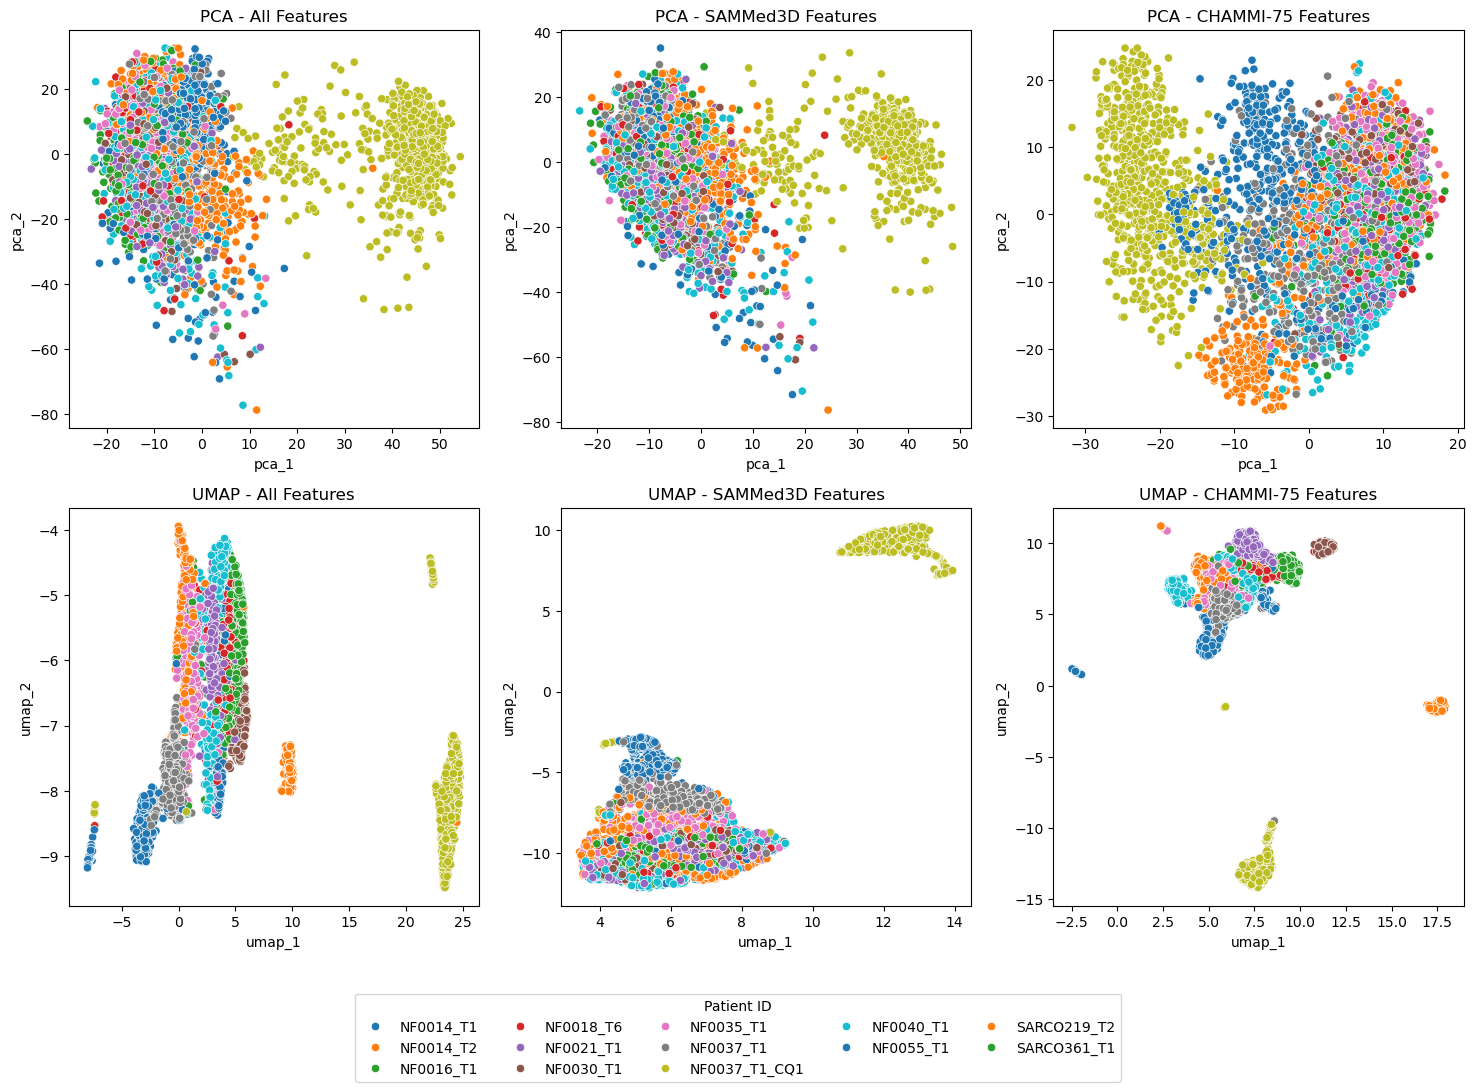

In [17]:
# set the order for the legend for the patient ID
patient_order = sorted(merged_df["patient"].unique())
all_features_projection_df["patient"] = pd.Categorical(
    all_features_projection_df["patient"], categories=patient_order, ordered=True
)
sammed_features_projection_df["patient"] = pd.Categorical(
    sammed_features_projection_df["patient"], categories=patient_order, ordered=True
)
morphem_features_projection_df["patient"] = pd.Categorical(
    morphem_features_projection_df["patient"], categories=patient_order, ordered=True
)
# plot PCA and UMAP for both features
# row 1: PCA, row 2: UMAP
# column 1: all features, column 2: sammed features, column 3: morphem features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
sns.scatterplot(
    data=all_features_projection_df,
    x="pca_1",
    y="pca_2",
    hue="patient",
    ax=axes[0, 0],
    palette="tab10",
)
# hide the legend for this subplot since we will add a single legend for all subplots at the end
axes[0, 0].set_title("PCA - All Features")
sns.scatterplot(
    data=sammed_features_projection_df,
    x="pca_1",
    y="pca_2",
    hue="patient",
    ax=axes[0, 1],
    palette="tab10",
)
axes[0, 1].set_title("PCA - SAMMed3D Features")
sns.scatterplot(
    data=morphem_features_projection_df,
    x="pca_1",
    y="pca_2",
    hue="patient",
    ax=axes[0, 2],
    palette="tab10",
)
axes[0, 2].set_title("PCA - morphem Features")
sns.scatterplot(
    data=all_features_projection_df,
    x="umap_1",
    y="umap_2",
    hue="patient",
    ax=axes[1, 0],
    palette="tab10",
)
axes[1, 0].set_title("UMAP - All Features")
sns.scatterplot(
    data=sammed_features_projection_df,
    x="umap_1",
    y="umap_2",
    hue="patient",
    ax=axes[1, 1],
    palette="tab10",
)
axes[1, 1].set_title("UMAP - SAMMed3D Features")
sns.scatterplot(
    data=morphem_features_projection_df,
    x="umap_1",
    y="umap_2",
    hue="patient",
    ax=axes[1, 2],
    palette="tab10",
)
axes[1, 2].set_title("UMAP - morphem Features")
# remove all subplot legends
for ax in axes.flatten():
    ax.get_legend().remove()
# move the legend to the bottom center of all subplots
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(patient_order) // 3 + 1,
    title="Patient ID",
)
# add padding for the legend
fig.subplots_adjust(bottom=0.15)
plt.show()

## Drop the CQ1 data

In [18]:
df = merged_df.loc[merged_df["patient"] != "NF0037_T1_CQ1"].copy()
feature_df = df.drop(columns=["patient", "well_fov"])
metadata_df = df[["patient", "well_fov"]]
sammed_features = df[[x for x in df.columns if "sammed" in x.lower()]]
morphem_features = df[[x for x in df.columns if "chammi" in x.lower()]]


all_features_projection_df = generate_umap_and_pca(feature_df, metadata_df.copy())
sammed_features_projection_df = generate_umap_and_pca(
    sammed_features, metadata_df.copy()
)
morphem_features_projection_df = generate_umap_and_pca(
    morphem_features, metadata_df.copy()
)

/home/lippincm/miniforge3/envs/GFF_segmentation/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lippincm/miniforge3/envs/GFF_segmentation/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lippincm/miniforge3/envs/GFF_segmentation/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


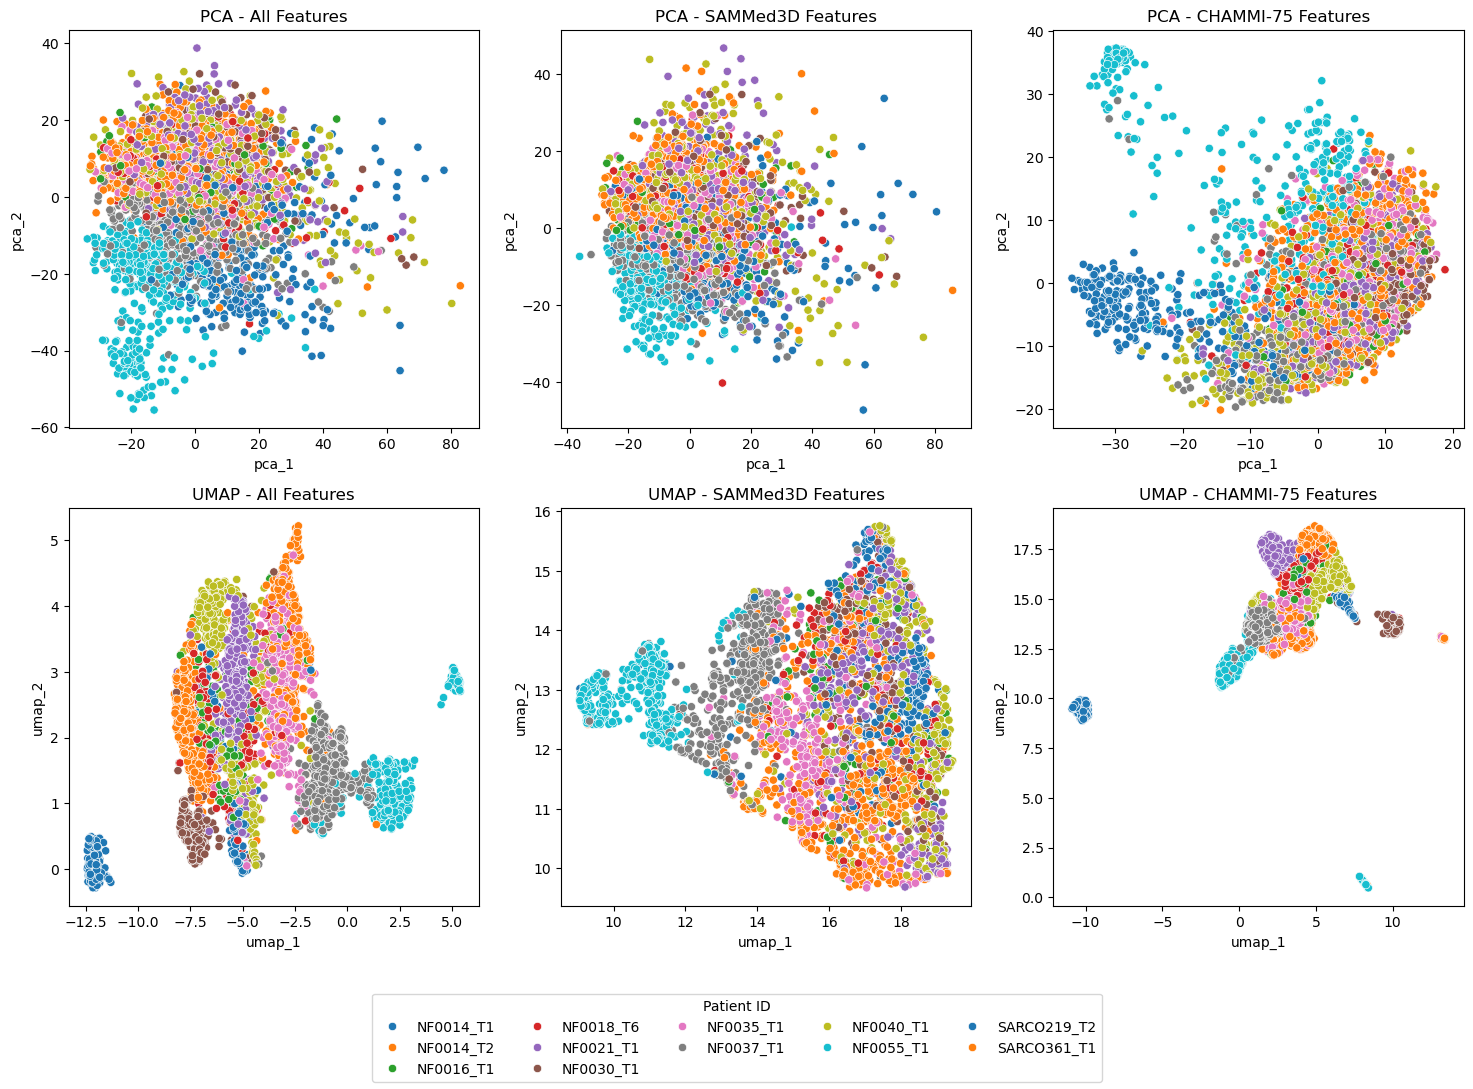

In [19]:
# set the order for the legend for the patient ID
patient_order = sorted(df["patient"].unique())
all_features_projection_df["patient"] = pd.Categorical(
    all_features_projection_df["patient"], categories=patient_order, ordered=True
)
sammed_features_projection_df["patient"] = pd.Categorical(
    sammed_features_projection_df["patient"], categories=patient_order, ordered=True
)
morphem_features_projection_df["patient"] = pd.Categorical(
    morphem_features_projection_df["patient"], categories=patient_order, ordered=True
)
# plot PCA and UMAP for both features
# row 1: PCA, row 2: UMAP
# column 1: all features, column 2: sammed features, column 3: morphem features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
sns.scatterplot(
    data=all_features_projection_df,
    x="pca_1",
    y="pca_2",
    hue="patient",
    ax=axes[0, 0],
    palette="tab10",
)
axes[0, 0].set_title("PCA - All Features")
sns.scatterplot(
    data=sammed_features_projection_df,
    x="pca_1",
    y="pca_2",
    hue="patient",
    ax=axes[0, 1],
    palette="tab10",
)
axes[0, 1].set_title("PCA - SAMMed3D Features")
sns.scatterplot(
    data=morphem_features_projection_df,
    x="pca_1",
    y="pca_2",
    hue="patient",
    ax=axes[0, 2],
    palette="tab10",
)
axes[0, 2].set_title("PCA - morphem Features")
sns.scatterplot(
    data=all_features_projection_df,
    x="umap_1",
    y="umap_2",
    hue="patient",
    ax=axes[1, 0],
    palette="tab10",
)
axes[1, 0].set_title("UMAP - All Features")
sns.scatterplot(
    data=sammed_features_projection_df,
    x="umap_1",
    y="umap_2",
    hue="patient",
    ax=axes[1, 1],
    palette="tab10",
)
axes[1, 1].set_title("UMAP - SAMMed3D Features")
sns.scatterplot(
    data=morphem_features_projection_df,
    x="umap_1",
    y="umap_2",
    hue="patient",
    ax=axes[1, 2],
    palette="tab10",
)
axes[1, 2].set_title("UMAP - morphem Features")
# remove all subplot legends
for ax in axes.flatten():
    ax.get_legend().remove()
# move the legend to the bottom center of all subplots
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(patient_order) // 3 + 1,
    title="Patient ID",
)
# add padding for the legend
fig.subplots_adjust(bottom=0.15)
plt.show()